In [2]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [3]:
df = pd.read_csv("D:/project/GBM/data/raw/booking.csv")

In [4]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [5]:
df.shape

(36285, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [7]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [8]:
df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [10]:
df["booking status"].value_counts()

booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64

In [11]:
df["booking status"].value_counts(normalize=True) * 100

booking status
Not_Canceled    67.234394
Canceled        32.765606
Name: proportion, dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number of adults,36285.0,1.844839,0.518813,0.0,2.0,2.00,2.0,4.0
number of children,36285.0,0.105360,0.402704,0.0,0.0,0.00,0.0,10.0
number of weekend nights,36285.0,0.810693,0.870590,0.0,0.0,1.00,2.0,7.0
number of week nights,36285.0,2.204602,1.410946,0.0,1.0,2.00,3.0,17.0
car parking space,36285.0,0.030977,0.173258,0.0,0.0,0.00,0.0,1.0
lead time,36285.0,85.239851,85.938796,0.0,17.0,57.00,126.0,443.0
repeated,36285.0,0.025630,0.158032,0.0,0.0,0.00,0.0,1.0
P-C,36285.0,0.023343,0.368281,0.0,0.0,0.00,0.0,13.0
P-not-C,36285.0,0.153369,1.753931,0.0,0.0,0.00,0.0,58.0
average price,36285.0,103.421636,35.086469,0.0,80.3,99.45,120.0,540.0


In [15]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Booking_ID
Booking_ID
INN36286    1
INN00001    1
INN00002    1
INN00003    1
INN00004    1
           ..
INN00018    1
INN00017    1
INN00016    1
INN00015    1
INN00014    1
Name: count, Length: 36285, dtype: int64

type of meal
type of meal
Meal Plan 1     27842
Not Selected     5132
Meal Plan 2      3306
Meal Plan 3         5
Name: count, dtype: int64

room type
room type
Room_Type 1    28138
Room_Type 4     6059
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

market segment type
market segment type
Online           23221
Offline          10531
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

date of reservation
date of reservation
10/13/2018    254
10/16/2017    236
6/15/2018     231
6/24/2018     213
9/18/2017     201
             ... 
7/24/2017       1
5/20/2017       1
10/2/2015       1
9/13/2016       1
7/21/2017       1
Name: count, Length: 553, 

In [16]:
df["booking status"] = df["booking status"].map({
    "Not_Canceled": 0,
    "Canceled": 1
})

In [17]:
df.drop(columns=["Booking_ID"], inplace=True)

In [19]:
df[['P-C', 'P-not-C']].describe()

for col in ['P-C', 'P-not-C']:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Value counts:")
    print(df[col].value_counts(dropna=False))


Column: P-C
Unique values: [ 0  3  1  2 11  4  5 13  6]
Value counts:
P-C
0     35947
1       198
2        46
3        43
11       25
5        11
4        10
13        4
6         1
Name: count, dtype: int64

Column: P-not-C
Unique values: [ 0  5  1  3  4 12 19  2 15 17  7 20 16 50 13  6 14 34 18  8 10 23 11 49
 47 53  9 33 22 24 52 21 48 28 39 25 31 38 26 51 42 37 35 56 44 27 32 55
 45 30 57 46 54 43 58 41 29 40 36]
Value counts:
P-not-C
0     35473
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
9        19
10       19
11       15
12       12
14        9
15        8
16        7
13        7
17        6
19        6
20        6
18        6
21        6
22        6
25        3
24        3
23        3
27        3
30        2
32        2
44        2
29        2
48        2
28        2
31        2
26        2
53        1
47        1
49        1
34        1
50        1
39        1
33        1
52        1
35        1
37        1
42        1
51  

In [20]:
df.groupby("booking status")["lead time"].mean()

booking status
0     58.933678
1    139.219615
Name: lead time, dtype: float64

In [21]:
df.groupby("booking status")["average price"].mean()

booking status
0     99.932994
1    110.580263
Name: average price, dtype: float64

In [22]:
pd.crosstab(
    df["repeated"],
    df["booking status"],
    normalize="index"
)

booking status,0,1
repeated,,
0,0.664178,0.335822
1,0.982796,0.017204


In [23]:
pd.crosstab(
    df["market segment type"],
    df["booking status"],
    normalize="index"
)

booking status,0,1
market segment type,,
Aviation,0.704000,0.296000
Complementary,1.000000,0.000000
Corporate,0.890927,0.109073
Offline,0.700503,0.299497
Online,0.634899,0.365101


In [24]:
df.groupby("booking status")["special requests"].mean()

booking status
0    0.758649
1    0.334679
Name: special requests, dtype: float64

In [30]:
df["date of reservation"].head()

0   2015-10-02
1   2018-11-06
2   2018-02-28
3   2017-05-20
4   2018-04-11
Name: date of reservation, dtype: datetime64[ns]

In [31]:
df["date of reservation"] = pd.to_datetime(
    df["date of reservation"],
    format='mixed',
    errors='coerce'
)

In [32]:
df["reservation_month"] = (
    df["date of reservation"].dt.month
)

df["reservation_dayofweek"] = (
    df["date of reservation"].dt.dayofweek
)

df["reservation_quarter"] = (
    df["date of reservation"].dt.quarter
)

df["is_weekend_booking"] = (
    df["date of reservation"].dt.dayofweek >= 5
).astype(int)

In [33]:
df.drop(
    columns=["date of reservation"],
    inplace=True
)

In [36]:
df1 = pd.read_csv("D:/project/GBM/data/raw/booking.csv")

In [37]:
# Create a copy
df_model = df1.copy()

In [38]:
df_model.drop(columns=["Booking_ID"], inplace=True)

In [42]:
df_model["date of reservation"].head()

0    10/2/2015
1    11/6/2018
2    2/28/2018
3    5/20/2017
4    4/11/2018
Name: date of reservation, dtype: object

In [46]:
df_model["date of reservation"] = pd.to_datetime(
    df1["date of reservation"],
    format='mixed',
    errors='coerce'
)

In [47]:
df_model["reservation_month"] = (
    df_model["date of reservation"].dt.month
)

df_model["reservation_dayofweek"] = (
    df_model["date of reservation"].dt.dayofweek
)

df_model["reservation_quarter"] = (
    df_model["date of reservation"].dt.quarter
)

df_model["is_weekend_booking"] = (
    df_model["date of reservation"].dt.dayofweek >= 5
).astype(int)

In [48]:
df_model.drop(
    columns=["date of reservation"],
    inplace=True
)

In [49]:
df_model["booking status"] = df_model["booking status"].map(
    {
        "Not_Canceled": 0,
        "Canceled": 1
    }
)

In [50]:
X = df_model.drop(
    columns=["booking status"]
)

y = df_model["booking status"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
categorical_features = (
    X_train
    .select_dtypes(include="object")
    .columns
    .tolist()
)

print(categorical_features)

['type of meal', 'room type', 'market segment type']


In [53]:
numerical_features = (
    X_train
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

print(numerical_features)

['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'car parking space', 'lead time', 'repeated', 'P-C', 'P-not-C', 'average price', 'special requests', 'reservation_month', 'reservation_dayofweek', 'reservation_quarter', 'is_weekend_booking']


In [54]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [55]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [56]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [83]:
baseline_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [84]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [85]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [86]:
y_pred = pipeline.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(7257,))

In [87]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_prob


array([0.71367521, 0.20523364, 0.20523364, ..., 0.        , 0.04070796,
       0.71367521], shape=(7257,))

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [89]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8383629599007855
Precision: 0.7729950158586316
Recall   : 0.7174095878889823
F1 Score : 0.744165757906216


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      4879
           1       0.77      0.72      0.74      2378

    accuracy                           0.84      7257
   macro avg       0.82      0.81      0.81      7257
weighted avg       0.84      0.84      0.84      7257



In [91]:
print(confusion_matrix(y_test, y_pred))

[[4378  501]
 [ 672 1706]]


In [92]:
train_pred = pipeline.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8326443433925864
Test Accuracy : 0.8383629599007855


In [93]:
from xgboost import XGBClassifier

In [94]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [95]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

In [96]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [98]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.8634421937439714
Precision: 0.8358353510895884
Recall   : 0.7258200168208578
F1 Score : 0.7769525095656088
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4879
           1       0.84      0.73      0.78      2378

    accuracy                           0.86      7257
   macro avg       0.86      0.83      0.84      7257
weighted avg       0.86      0.86      0.86      7257

[[4540  339]
 [ 652 1726]]


In [99]:
train_pred_xgb = xgb_pipeline.predict(X_train)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred_xgb))
print("Test Accuracy :",
      accuracy_score(y_test, y_pred_xgb))

Train Accuracy: 0.8595149510817142
Test Accuracy : 0.8634421937439714


In [100]:
from lightgbm import LGBMClassifier


In [101]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    num_leaves=31,
    random_state=42
)


In [102]:
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", lgbm_model)
    ]
)


In [103]:
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9511, number of negative: 19517
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 640
[LightGBM] [Info] Number of data points in the train set: 29028, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.327649 -> initscore=-0.718837
[LightGBM] [Info] Start training from score -0.718837
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
y_pred_lgbm = lgbm_pipeline.predict(X_test)

d:\project\GBM\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [105]:
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))

Accuracy : 0.8639933856965688
Precision: 0.8342143200384431
Recall   : 0.7300252312867956
F1 Score : 0.7786499215070644
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4879
           1       0.83      0.73      0.78      2378

    accuracy                           0.86      7257
   macro avg       0.86      0.83      0.84      7257
weighted avg       0.86      0.86      0.86      7257

[[4534  345]
 [ 642 1736]]


In [106]:
train_pred_lgbm = lgbm_pipeline.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred_lgbm))
print("Test Accuracy :", accuracy_score(y_test, y_pred_lgbm))

Train Accuracy: 0.860892930963208
Test Accuracy : 0.8639933856965688


d:\project\GBM\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [107]:
from catboost import CatBoostClassifier

In [108]:
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=4,
    random_state=42,
    verbose=0
)

In [109]:
cat_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", cat_model)
    ]
)

In [110]:
cat_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
y_pred_cat = cat_pipeline.predict(X_test)

In [113]:
print("Accuracy :", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall   :", recall_score(y_test, y_pred_cat))
print("F1 Score :", f1_score(y_test, y_pred_cat))

print(classification_report(y_test, y_pred_cat))
print(confusion_matrix(y_test, y_pred_cat))

Accuracy : 0.8594460520876395
Precision: 0.8384845463609173
Recall   : 0.7073170731707317
F1 Score : 0.7673357664233577
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4879
           1       0.84      0.71      0.77      2378

    accuracy                           0.86      7257
   macro avg       0.85      0.82      0.83      7257
weighted avg       0.86      0.86      0.86      7257

[[4555  324]
 [ 696 1682]]


In [114]:
train_pred_cat = cat_pipeline.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred_cat))
print("Test Accuracy :", accuracy_score(y_test, y_pred_cat))

Train Accuracy: 0.8546231225024115
Test Accuracy : 0.8594460520876395


In [118]:
best_pipeline = lgbm_pipeline

In [119]:
import shap
import matplotlib.pyplot as plt

In [120]:
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["classifier"]

In [121]:
X_test_processed = preprocessor.transform(X_test)

In [122]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

d:\project\GBM\.venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [123]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__number of adults' 'num__number of children'
 'num__number of weekend nights' 'num__number of week nights'
 'num__car parking space' 'num__lead time' 'num__repeated' 'num__P-C'
 'num__P-not-C' 'num__average price' 'num__special requests'
 'num__reservation_month' 'num__reservation_dayofweek'
 'num__reservation_quarter' 'num__is_weekend_booking'
 'cat__type of meal_Meal Plan 1' 'cat__type of meal_Meal Plan 2'
 'cat__type of meal_Meal Plan 3' 'cat__type of meal_Not Selected'
 'cat__room type_Room_Type 1' 'cat__room type_Room_Type 2'
 'cat__room type_Room_Type 3' 'cat__room type_Room_Type 4'
 'cat__room type_Room_Type 5' 'cat__room type_Room_Type 6'
 'cat__room type_Room_Type 7' 'cat__market segment type_Aviation'
 'cat__market segment type_Complementary'
 'cat__market segment type_Corporate' 'cat__market segment type_Offline'
 'cat__market segment type_Online']


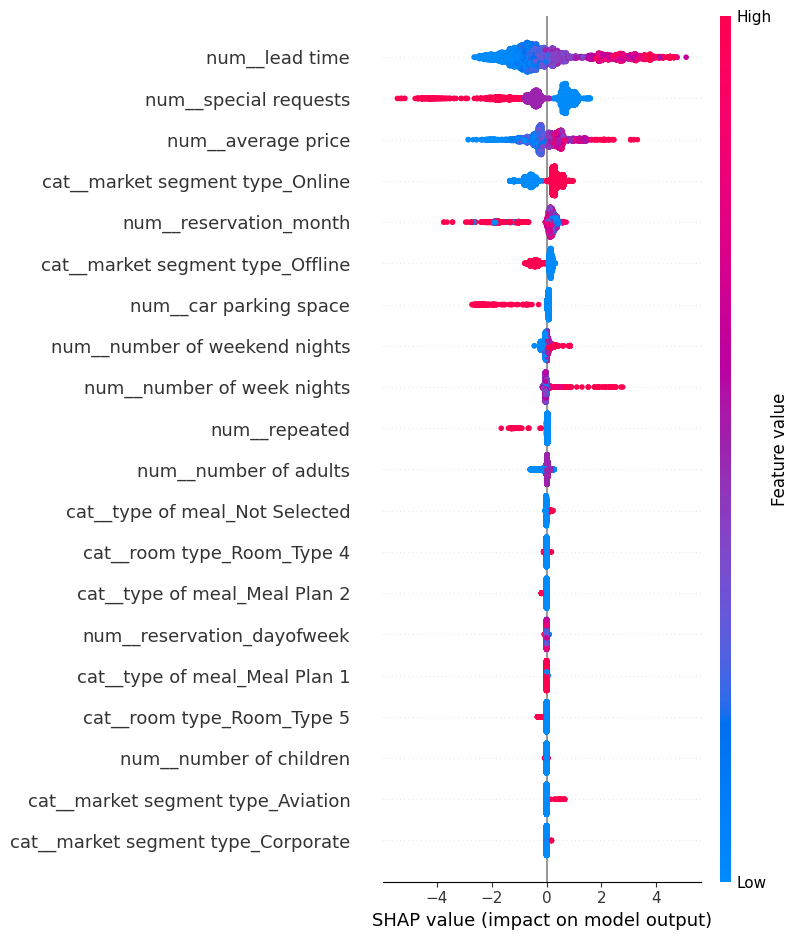

In [124]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

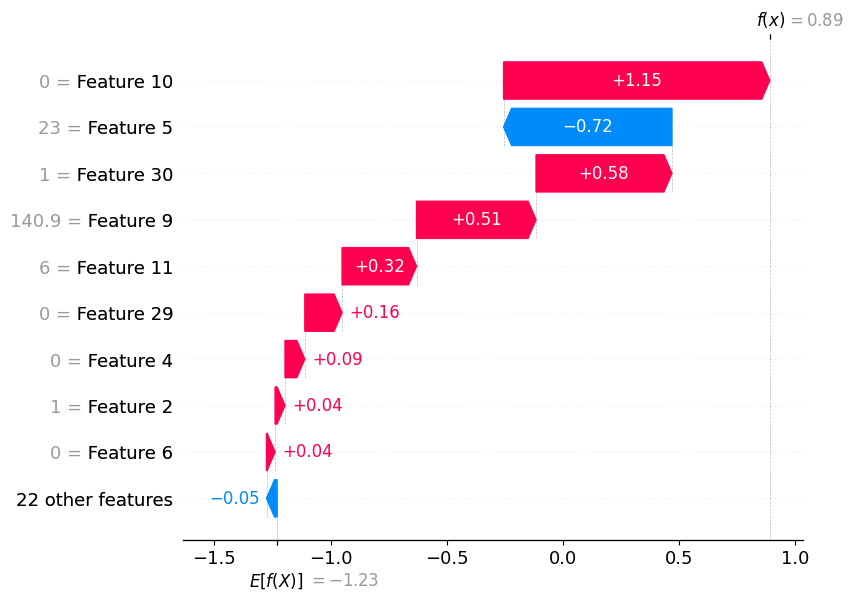

In [125]:
shap.plots.waterfall(
    explainer(
        X_test_processed[:1]
    )[0]
)

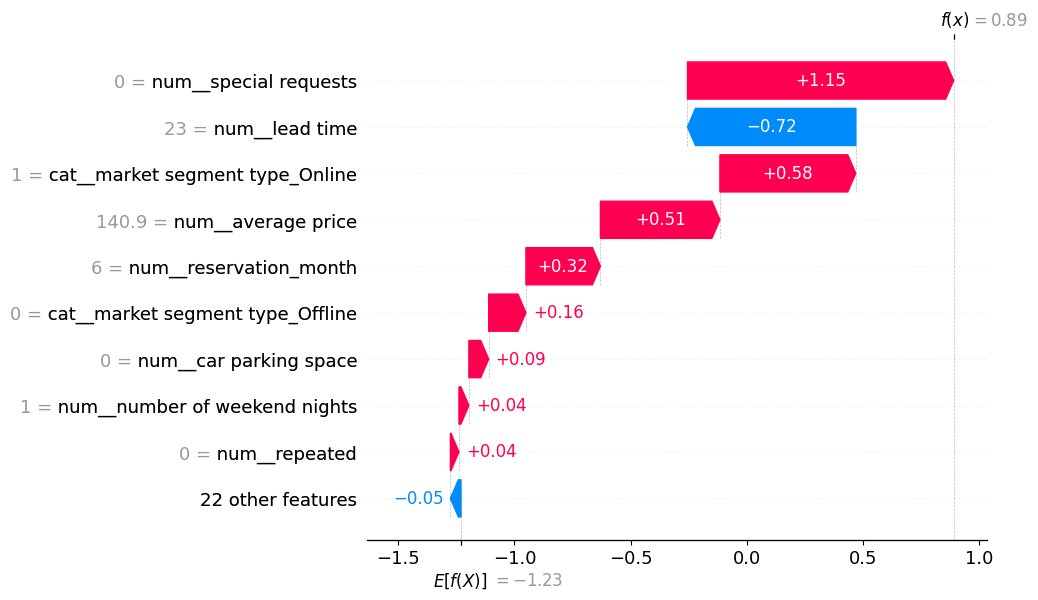

In [126]:
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Transform test data
X_test_processed = preprocessor.transform(X_test)

# Create a DataFrame with proper names
import pandas as pd

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

# Create SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_shap)

# Waterfall plot for first sample
shap.plots.waterfall(shap_values[0])


In [128]:
import joblib
joblib.dump(
    best_pipeline,
    "D:/project/GBM/models/hotel_cancellation_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
